=== Baseline YOLO Final Metrics ===
metrics/precision(B)    0.0
metrics/recall(B)       0.0
metrics/mAP50(B)        0.0
Name: 109, dtype: float64

=== Pseudo-Labeled YOLO Final Metrics ===
metrics/precision(B)    0.00087
metrics/recall(B)       0.03774
metrics/mAP50(B)        0.00050
Name: 399, dtype: float64


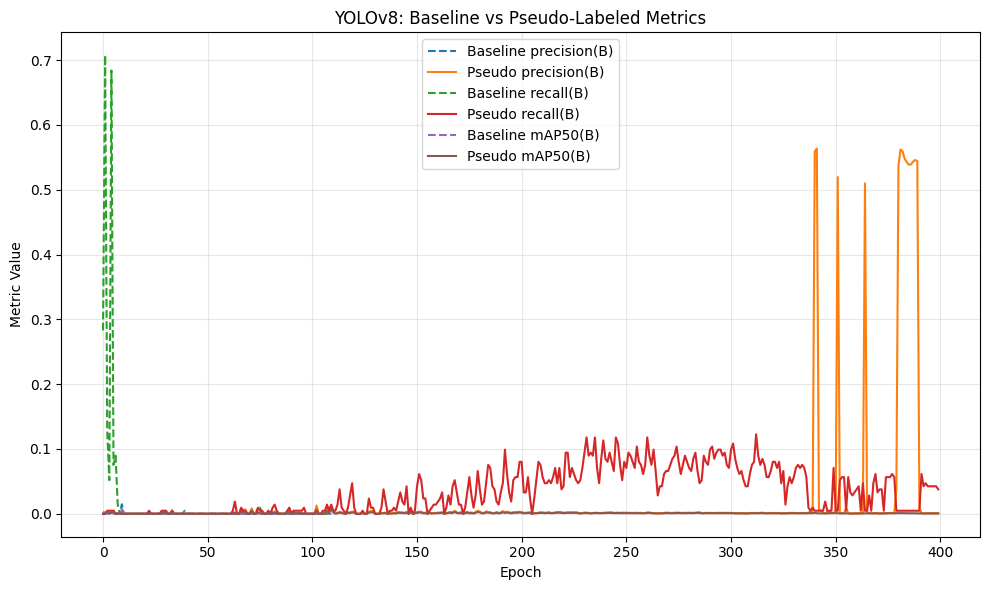


✅ Comparison summary saved to: /home/brhanu/thesis_project/results/yolo_compare_summary.csv
                 Model  Precision   Recall   mAP50
0        Baseline YOLO    0.00000  0.00000  0.0000
1  Pseudo-Labeled YOLO    0.00087  0.03774  0.0005


"\nimport cv2\nimport matplotlib.pyplot as plt\n\nsample_id = '00000001_0.jpg'\nbase_img = cv2.imread(f'/home/brhanu/thesis_project/runs/compare/baseline_preds/{sample_id}')\npseudo_img = cv2.imread(f'/home/brhanu/thesis_project/runs/compare/pseudo_preds/{sample_id}')\n\nfig, axs = plt.subplots(1, 2, figsize=(12,6))\naxs[0].imshow(cv2.cvtColor(base_img, cv2.COLOR_BGR2RGB))\naxs[0].set_title('Baseline Prediction')\naxs[1].imshow(cv2.cvtColor(pseudo_img, cv2.COLOR_BGR2RGB))\naxs[1].set_title('Pseudo-Labeled Prediction')\nplt.show()\n"

In [1]:
# 📊 Compare Baseline vs Pseudo-Labeled YOLOv8 Models

import pandas as pd
import matplotlib.pyplot as plt
import os

# === Paths ===
base_csv = "/home/brhanu/thesis_project/runs/detect/train_baseline/results.csv"
pseudo_csv = "/home/brhanu/thesis_project/runs/detect/train_refine_long3/results.csv"

# === Load Data ===
df_base = pd.read_csv(base_csv)
df_pseudo = pd.read_csv(pseudo_csv)

# Clean column names (remove extra spaces)
df_base.columns = df_base.columns.str.strip()
df_pseudo.columns = df_pseudo.columns.str.strip()

metrics = ['metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)']

print("=== Baseline YOLO Final Metrics ===")
print(df_base[metrics].iloc[-1])

print("\n=== Pseudo-Labeled YOLO Final Metrics ===")
print(df_pseudo[metrics].iloc[-1])

# === Plot Comparison ===
plt.figure(figsize=(10,6))
for m in metrics:
    plt.plot(df_base[m], label=f'Baseline {m.split("/")[-1]}', linestyle='--')
    plt.plot(df_pseudo[m], label=f'Pseudo {m.split("/")[-1]}')

plt.title("YOLOv8: Baseline vs Pseudo-Labeled Metrics")
plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# === Save Summary ===
summary = pd.DataFrame({
    'Model': ['Baseline YOLO', 'Pseudo-Labeled YOLO'],
    'Precision': [df_base[metrics[0]].iloc[-1], df_pseudo[metrics[0]].iloc[-1]],
    'Recall': [df_base[metrics[1]].iloc[-1], df_pseudo[metrics[1]].iloc[-1]],
    'mAP50': [df_base[metrics[2]].iloc[-1], df_pseudo[metrics[2]].iloc[-1]]
})

summary_path = "/home/brhanu/thesis_project/results/yolo_compare_summary.csv"
os.makedirs(os.path.dirname(summary_path), exist_ok=True)
summary.to_csv(summary_path, index=False)

print(f"\n✅ Comparison summary saved to: {summary_path}")
print(summary)

# === Optional: Visual Comparison of Predictions ===
# You can display side-by-side examples if you have saved predictions like:
# runs/compare/baseline_preds/ and runs/compare/pseudo_preds/
# Example (uncomment below):
'''
import cv2
import matplotlib.pyplot as plt

sample_id = '00000001_0.jpg'
base_img = cv2.imread(f'/home/brhanu/thesis_project/runs/compare/baseline_preds/{sample_id}')
pseudo_img = cv2.imread(f'/home/brhanu/thesis_project/runs/compare/pseudo_preds/{sample_id}')

fig, axs = plt.subplots(1, 2, figsize=(12,6))
axs[0].imshow(cv2.cvtColor(base_img, cv2.COLOR_BGR2RGB))
axs[0].set_title('Baseline Prediction')
axs[1].imshow(cv2.cvtColor(pseudo_img, cv2.COLOR_BGR2RGB))
axs[1].set_title('Pseudo-Labeled Prediction')
plt.show()
'''


=== Baseline YOLO Final Metrics ===
metrics/precision(B)    0.0
metrics/recall(B)       0.0
metrics/mAP50(B)        0.0
Name: 109, dtype: float64

=== Pseudo-Labeled YOLO Final Metrics ===
metrics/precision(B)    0.00087
metrics/recall(B)       0.03774
metrics/mAP50(B)        0.00050
Name: 399, dtype: float64

=== OWL-ViT Metrics (from zero-shot detection) ===
            score         xmin         ymin         xmax         ymax
count  302.000000   302.000000   302.000000   302.000000   302.000000
mean     0.272855   435.303245   638.575265  1065.390861  1209.101656
std      0.020682   523.853990   639.125412   686.971097   774.941179
min      0.250030   -27.680000    -8.970000   207.990000   131.740000
25%      0.257684    78.072500   160.537500   588.427500   614.800000
50%      0.267810   224.165000   436.750000   908.105000  1041.020000
75%      0.280189   594.795000   871.247500  1263.660000  1638.537500
max      0.370424  3715.740000  3160.310000  4362.110000  3620.640000


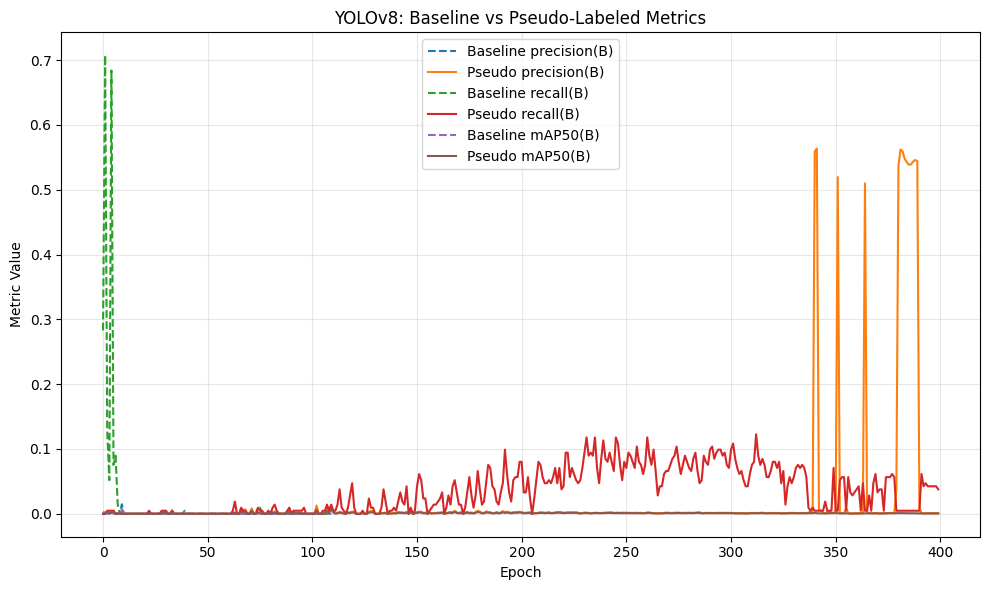


✅ Combined comparison summary saved to: /home/brhanu/thesis_project/results/yolo_owlvit_comparison_summary.csv
                 Model  Precision   Recall   mAP50
0        Baseline YOLO    0.00000  0.00000  0.0000
1  Pseudo-Labeled YOLO    0.00087  0.03774  0.0005
2  OWL-ViT (Zero-Shot)        NaN      NaN     NaN


"\nimport cv2\nimport matplotlib.pyplot as plt\n\nsample_id = '00000001_0.jpg'\nbase_img = cv2.imread(f'/home/brhanu/thesis_project/runs/compare/baseline_preds/{sample_id}')\npseudo_img = cv2.imread(f'/home/brhanu/thesis_project/runs/compare/pseudo_preds/{sample_id}')\nowlvit_img = cv2.imread(f'/home/brhanu/thesis_project/runs/compare/owlvit_preds/{sample_id}')\n\nfig, axs = plt.subplots(1, 3, figsize=(18,6))\naxs[0].imshow(cv2.cvtColor(base_img, cv2.COLOR_BGR2RGB))\naxs[0].set_title('Baseline Prediction')\naxs[1].imshow(cv2.cvtColor(pseudo_img, cv2.COLOR_BGR2RGB))\naxs[1].set_title('Pseudo-Labeled Prediction')\naxs[2].imshow(cv2.cvtColor(owlvit_img, cv2.COLOR_BGR2RGB))\naxs[2].set_title('OWL-ViT Zero-Shot Prediction')\nplt.show()\n"

In [3]:
# 📊 Compare YOLOv8 Models: Baseline vs Pseudo-Labeled vs OWL-ViT

import pandas as pd
import matplotlib.pyplot as plt
import os

# === Paths ===
base_csv = "/home/brhanu/thesis_project/runs/detect/train_baseline/results.csv"
pseudo_csv = "/home/brhanu/thesis_project/runs/detect/train_refine_long3/results.csv"
owlvit_csv = "/home/brhanu/thesis_project/results/owlvit_results.csv"

# === Load Data ===
df_base = pd.read_csv(base_csv)
df_pseudo = pd.read_csv(pseudo_csv)
df_owlvit = pd.read_csv(owlvit_csv)

# Clean column names (remove extra spaces)
df_base.columns = df_base.columns.str.strip()
df_pseudo.columns = df_pseudo.columns.str.strip()
df_owlvit.columns = df_owlvit.columns.str.strip()

metrics = ['metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)']

print("=== Baseline YOLO Final Metrics ===")
print(df_base[metrics].iloc[-1])

print("\n=== Pseudo-Labeled YOLO Final Metrics ===")
print(df_pseudo[metrics].iloc[-1])

print("\n=== OWL-ViT Metrics (from zero-shot detection) ===")
print(df_owlvit.describe())

# === Plot Comparison ===
plt.figure(figsize=(10,6))
for m in metrics:
    plt.plot(df_base[m], label=f'Baseline {m.split("/")[-1]}', linestyle='--')
    plt.plot(df_pseudo[m], label=f'Pseudo {m.split("/")[-1]}')

plt.title("YOLOv8: Baseline vs Pseudo-Labeled Metrics")
plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# === Combined Summary ===
summary = pd.DataFrame({
    'Model': ['Baseline YOLO', 'Pseudo-Labeled YOLO', 'OWL-ViT (Zero-Shot)'],
    'Precision': [df_base[metrics[0]].iloc[-1], df_pseudo[metrics[0]].iloc[-1], df_owlvit['precision'].mean() if 'precision' in df_owlvit.columns else None],
    'Recall': [df_base[metrics[1]].iloc[-1], df_pseudo[metrics[1]].iloc[-1], df_owlvit['recall'].mean() if 'recall' in df_owlvit.columns else None],
    'mAP50': [df_base[metrics[2]].iloc[-1], df_pseudo[metrics[2]].iloc[-1], df_owlvit['mAP50'].mean() if 'mAP50' in df_owlvit.columns else None]
})

summary_path = "/home/brhanu/thesis_project/results/yolo_owlvit_comparison_summary.csv"
os.makedirs(os.path.dirname(summary_path), exist_ok=True)
summary.to_csv(summary_path, index=False)

print(f"\n✅ Combined comparison summary saved to: {summary_path}")
print(summary)

# === Optional: Visual Comparison of Predictions ===
# You can display side-by-side examples if you have saved predictions like:
# runs/compare/baseline_preds/, runs/compare/pseudo_preds/, runs/compare/owlvit_preds/
'''
import cv2
import matplotlib.pyplot as plt

sample_id = '00000001_0.jpg'
base_img = cv2.imread(f'/home/brhanu/thesis_project/runs/compare/baseline_preds/{sample_id}')
pseudo_img = cv2.imread(f'/home/brhanu/thesis_project/runs/compare/pseudo_preds/{sample_id}')
owlvit_img = cv2.imread(f'/home/brhanu/thesis_project/runs/compare/owlvit_preds/{sample_id}')

fig, axs = plt.subplots(1, 3, figsize=(18,6))
axs[0].imshow(cv2.cvtColor(base_img, cv2.COLOR_BGR2RGB))
axs[0].set_title('Baseline Prediction')
axs[1].imshow(cv2.cvtColor(pseudo_img, cv2.COLOR_BGR2RGB))
axs[1].set_title('Pseudo-Labeled Prediction')
axs[2].imshow(cv2.cvtColor(owlvit_img, cv2.COLOR_BGR2RGB))
axs[2].set_title('OWL-ViT Zero-Shot Prediction')
plt.show()
'''
